In [ ]:
#@title Step 1: Load Data and packages
import matplotlib.pyplot as plt
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
import os
import dlib
import time
from skimage import feature
from IPython.display import HTML, display
from IPython.display import clear_output

#Function for progress bar.
def progress(value, max=100):
    return HTML("""<progress value='{value}' max='{max}', style='width: 100%'>
            {value}
        </progress>""".format(value=value, max=max))

from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

downloaded = drive.CreateFile({'id': '188vqkvzALst-zhXt-wl2oxt24w3H-Dv_'})
downloaded.GetContentFile('face_verification.zip')        # replace the file name with your file
!unzip face_verification
clear_output()
print('Done! Press the Refresh button if files are not visible.')

Done! Press the Refresh button if files are not visible.


In [ ]:
#@title Step 2: Install the Deepface package
!pip install deepface
clear_output()

In [ ]:
#@title Step 3: Import the package

from deepface import DeepFace

24-04-29 14:42:17 - Directory /root/.deepface created
24-04-29 14:42:17 - Directory /root/.deepface/weights created


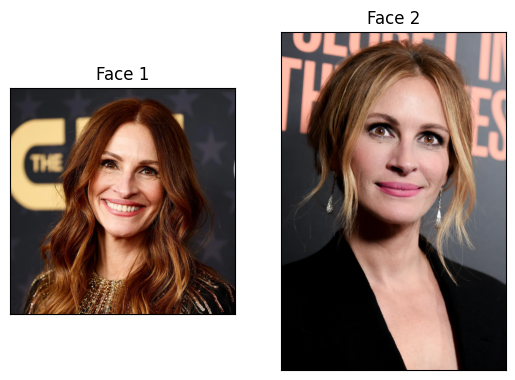

In [ ]:
#@title Step 4: Visualization of two images

face1 = cv2.imread("/content/face_verification/1.png")
face1 = cv2.cvtColor(face1, cv2.COLOR_BGR2RGB)
face2 = cv2.imread("/content/face_verification/3.png")
face2 = cv2.cvtColor(face2, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2)
ax[0].imshow(face1)
ax[0].set_title("Face 1")
ax[1].imshow(face2)
ax[1].set_title("Face 2")
ax[0].tick_params(left = False, right = False , labelleft = False ,
                labelbottom = False, bottom = False)
ax[1].tick_params(left = False, right = False , labelleft = False ,
                labelbottom = False, bottom = False)
plt.show()

In [ ]:
#@title Step 5: Verification


result = DeepFace.verify(img1_path = "/content/face_verification/1.png", img2_path = "/content/face_verification/3.png")

print(result)


24-04-29 14:44:34 - vgg_face_weights.h5 will be downloaded...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5
To: /root/.deepface/weights/vgg_face_weights.h5
100%|██████████| 580M/580M [00:02<00:00, 274MB/s]


{'verified': True, 'distance': 0.4359580495881631, 'threshold': 0.68, 'model': 'VGG-Face', 'detector_backend': 'opencv', 'similarity_metric': 'cosine', 'facial_areas': {'img1': {'x': 397, 'y': 248, 'w': 520, 'h': 520, 'left_eye': (732, 461), 'right_eye': (548, 426)}, 'img2': {'x': 376, 'y': 334, 'w': 939, 'h': 939, 'left_eye': (1020, 743), 'right_eye': (682, 685)}}, 'time': 10.87}


In [ ]:

facial_area1 = result['facial_areas']['img1']
facial_area2 = result['facial_areas']['img2']

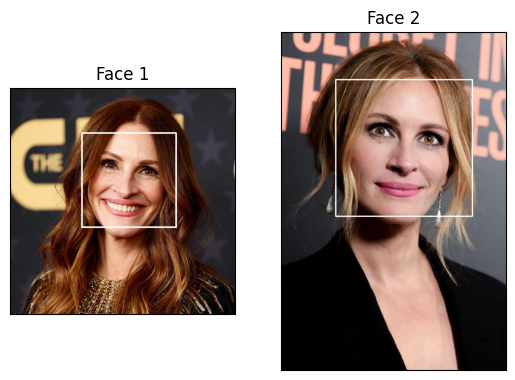

Verified:  True
Distance:  0.4359580495881631
Max threshold:  0.68
Model:  VGG-Face
Similarity metric: cosine


In [ ]:
#@title Let's see the result

cv2.rectangle(face1, (facial_area1['x'], facial_area1['y']) #draw a rectangle delimiting the face area
   , (facial_area1['x'] + facial_area1['w'], facial_area1['y'] + facial_area1['h']), (255, 255, 255), 8)

cv2.rectangle(face2, (facial_area2['x'], facial_area2['y']) #draw a rectangle delimiting the face area
   , (facial_area2['x'] + facial_area2['w'], facial_area2['y'] + facial_area2['h']), (255, 255, 255), 8)

fig, ax = plt.subplots(1, 2)
ax[0].imshow(face1)
ax[0].set_title("Face 1")
ax[1].imshow(face2)
ax[1].set_title("Face 2")
ax[0].tick_params(left = False, right = False , labelleft = False ,
                labelbottom = False, bottom = False)
ax[1].tick_params(left = False, right = False , labelleft = False ,
                labelbottom = False, bottom = False)
plt.show()

print("Verified: ", result['verified'])
print("Distance: ", result['distance'])
print("Max threshold: ", result['threshold'])
print("Model: ", result['model'])
print("Similarity metric:", result['similarity_metric'])

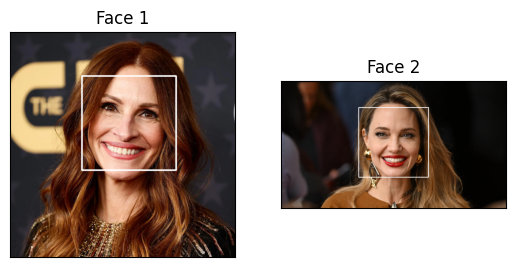

Verified:  False
Distance:  0.9025083437047005
Max threshold:  0.68
Model:  VGG-Face
Similarity metric: cosine


In [ ]:
#@title Step 6: Try with two different identities


face1 = cv2.imread("/content/face_verification/1.png")
face1 = cv2.cvtColor(face1, cv2.COLOR_BGR2RGB)
face2 = cv2.imread("/content/face_verification/4.png")
face2 = cv2.cvtColor(face2, cv2.COLOR_BGR2RGB)


result = DeepFace.verify(img1_path = "/content/face_verification/1.png", img2_path = "/content/face_verification/4.png")


facial_area1 = result['facial_areas']['img1']
facial_area2 = result['facial_areas']['img2']

cv2.rectangle(face1, (facial_area1['x'], facial_area1['y']) #draw a rectangle delimiting the face area
   , (facial_area1['x'] + facial_area1['w'], facial_area1['y'] + facial_area1['h']), (255, 255, 255), 8)

cv2.rectangle(face2, (facial_area2['x'], facial_area2['y']) #draw a rectangle delimiting the face area
   , (facial_area2['x'] + facial_area2['w'], facial_area2['y'] + facial_area2['h']), (255, 255, 255), 8)

fig, ax = plt.subplots(1, 2)
ax[0].imshow(face1)
ax[0].set_title("Face 1")
ax[1].imshow(face2)
ax[1].set_title("Face 2")
ax[0].tick_params(left = False, right = False , labelleft = False ,
                labelbottom = False, bottom = False)
ax[1].tick_params(left = False, right = False , labelleft = False ,
                labelbottom = False, bottom = False)
plt.show()

print("Verified: ", result['verified'])
print("Distance: ", result['distance'])
print("Max threshold: ", result['threshold'])
print("Model: ", result['model'])
print("Similarity metric:", result['similarity_metric'])

# What if we try with two images of the same person but at different ages?


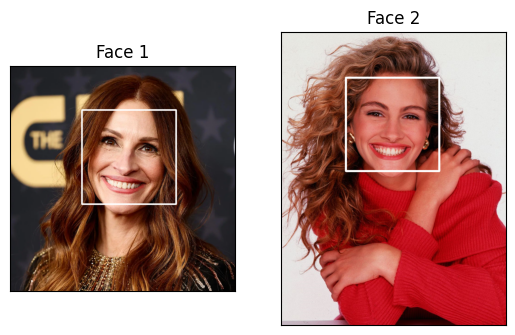

Verified:  False
Distance:  0.6918163258439733
Max threshold:  0.68
Model:  VGG-Face
Similarity metric: cosine


In [ ]:
face1 = cv2.imread("/content/face_verification/1.png")
face1 = cv2.cvtColor(face1, cv2.COLOR_BGR2RGB)
face2 = cv2.imread("/content/face_verification/2.png")
face2 = cv2.cvtColor(face2, cv2.COLOR_BGR2RGB)


result = DeepFace.verify(img1_path = "/content/face_verification/1.png", img2_path = "/content/face_verification/2.png")


facial_area1 = result['facial_areas']['img1']
facial_area2 = result['facial_areas']['img2']

cv2.rectangle(face1, (facial_area1['x'], facial_area1['y']) #draw a rectangle delimiting the face area
   , (facial_area1['x'] + facial_area1['w'], facial_area1['y'] + facial_area1['h']), (255, 255, 255), 8)

cv2.rectangle(face2, (facial_area2['x'], facial_area2['y']) #draw a rectangle delimiting the face area
   , (facial_area2['x'] + facial_area2['w'], facial_area2['y'] + facial_area2['h']), (255, 255, 255), 8)

fig, ax = plt.subplots(1, 2)
ax[0].imshow(face1)
ax[0].set_title("Face 1")
ax[1].imshow(face2)
ax[1].set_title("Face 2")
ax[0].tick_params(left = False, right = False , labelleft = False ,
                labelbottom = False, bottom = False)
ax[1].tick_params(left = False, right = False , labelleft = False ,
                labelbottom = False, bottom = False)
plt.show()

print("Verified: ", result['verified'])
print("Distance: ", result['distance'])
print("Max threshold: ", result['threshold'])
print("Model: ", result['model'])
print("Similarity metric:", result['similarity_metric'])

# We get an error! This is one of the main issues related to face recognition. We will see some techniques that can be used to avoid it.